#Problem statement: Segment the customers based on Age, Annual income, spending score
Our company's goal is to identify the customer groups for personalized target marketing

#Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.cluster import KMeans


#Load the dataset

In [2]:
df=pd.read_csv('/content/Mall_Customers.csv')


In [3]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


# Basic Datacheck

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.shape

(200, 5)

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#Identify and remove the column with all unique values

In [7]:
df=df.drop('CustomerID',axis=1)

In [8]:
df


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [9]:
#check for null values
df.isnull().sum()

,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Comment:There are no null values in the dataset

In [10]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

Comment:There are no duplicate values in the dataset

# Split data into categorical and numerical column

In [11]:
categorical_columns=df.select_dtypes(include='object').columns
numerical_columns=df.select_dtypes(exclude='object').columns

In [12]:
categorical_columns

Index(['Gender'], dtype='object')

In [13]:
numerical_columns

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [14]:
#check for error values
for i in df:
  print(df[i].value_counts())
  print("-----"*50)

Gender
Female    112
Male       88
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Age
32    11
35     9
31     8
19     8
30     7
49     7
23     6
40     6
36     6
27     6
47     6
38     6
50     5
20     5
21     5
29     5
48     5
34     5
67     4
54     4
24     4
59     4
18     4
28     4
22     3
25     3
46     3
43     3
39     3
60     3
45     3
37     3
33     3
68     3
58     2
41     2
52     2
57     2
65     2
53     2
51     2
42     2
70     2
44     2
26     2
63     2
66     2
64     1
69     1
55     1
56     1
Name: count, dtype: int64
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Comment:There are no error values

In [15]:
#outliers detection
for col in numerical_columns:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)

  iqr=q3-q1
  lb=q1-1.5*iqr
  ub=q3+1.5*iqr
  outliers=df[(df[col]<lb)|(df[col]>ub)]
  #print(len(outliers))
  #print("-----"*50)
  df_iqr=df[(df[col]>=lb)&(df[col]<=ub)]


In [16]:
df_iqr

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [17]:
print(df.shape)
print(df_iqr.shape)

(200, 4)
(200, 4)


Comment:As shape of both dataset  i.e. df before removing outlier and df after removing outlier is same. So there are no outliers in the dataset

# Univariate Analysis

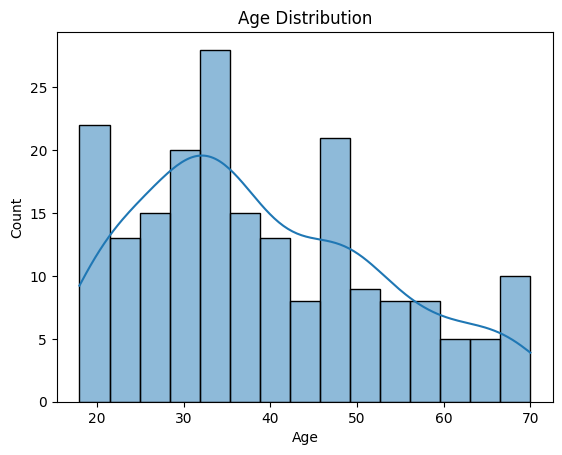

In [18]:
sns.histplot(df_iqr['Age'],bins=15,kde=True)
plt.title("Age Distribution")
plt.show()

Comment:Most of the customers are concentrated in 20-40 age range,with thw peak around 30-35 yrs.after that frequency gradually declines,especially in the 60+range. This means cutomer base is skewed towards younger adults.

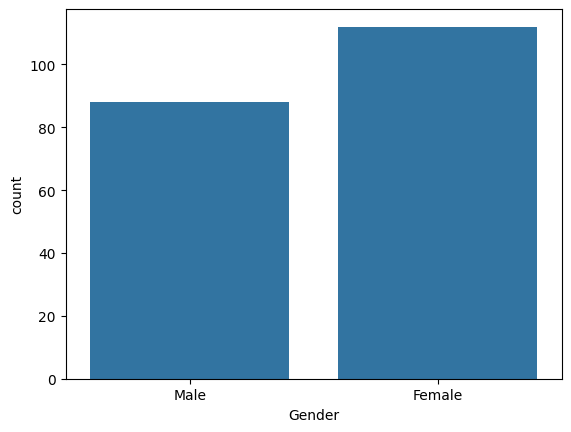

In [19]:
sns.countplot(df_iqr,x='Gender')
plt.show()

Comment:


*   No of female customers ountnumber the male customers
*   Difference is noticeable but not extreme.
*   Strategies targeting female will may reach larger audience.





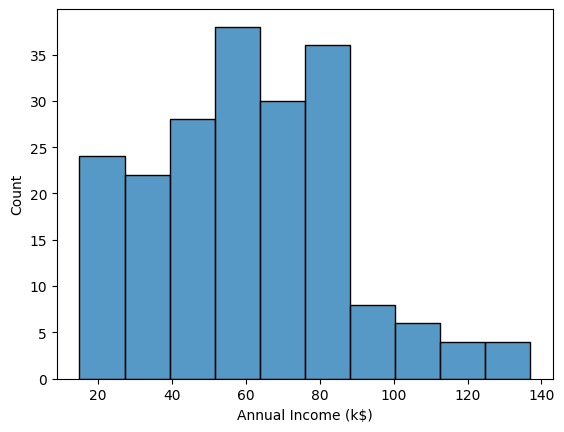

In [20]:
sns.histplot(df_iqr['Annual Income (k$)'],bins=10)
plt.show()

Comment:

*   Most of the customers fall into the 60–80k range.
*   The distribution is right-skewed.
*  There is a small group of        customers clustered at the higher range. Sharp decline after 80k highlights income inequality.
*   This is typical of income data where fewer people earn very high than the majority.





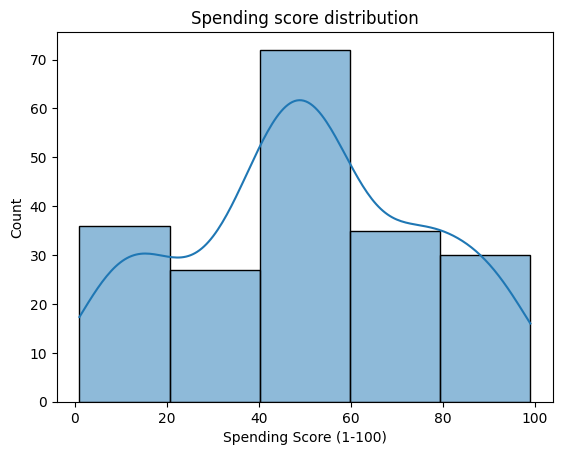

In [21]:
sns.histplot(df_iqr['Spending Score (1-100)'],bins=5,kde=True)
plt.title("Spending score distribution")
plt.show()

Comment:


*   Larger group have spending score of 40-60.
*   It shows most of people fall under moderate spending score category, neighter too high nor too low.
*   As most customers are moderate spenders strategies should be focusing on them to target.







In [22]:
#convert categorical col(Gender) to numeric
df_iqr['Gender']=df_iqr['Gender'].map({'Male':0,'Female':1})

In [23]:
df_iqr

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40
...,...,...,...,...
195,1,35,120,79
196,1,45,126,28
197,0,32,126,74
198,0,32,137,18


# Bivariate analysis

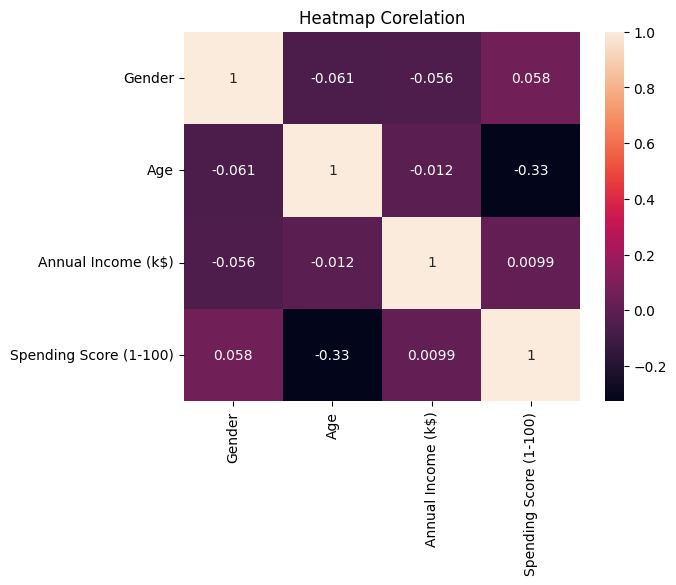

In [24]:
sns.heatmap(df_iqr.corr(),annot=True)
plt.title("Heatmap Corelation")
plt.show()

comment:

*   Gender has very weak correlations
with Age (-0.061), Income (-0.056), and Spending Score (0.058).This means gender doesn’t strongly influence income or spending behavior in dataset.
*   Age vs. Spending Score: -0.33 (moderate negative correlation).
Younger customers tend to have higher spending scores, while older customers spend less.

*   Age vs. Income: -0.012 (almost no relationship).
*   Spending Score correlations:
Strongest relationship is with Age (-0.33).

*   Age is the most predictive factor for spending score among these variables.












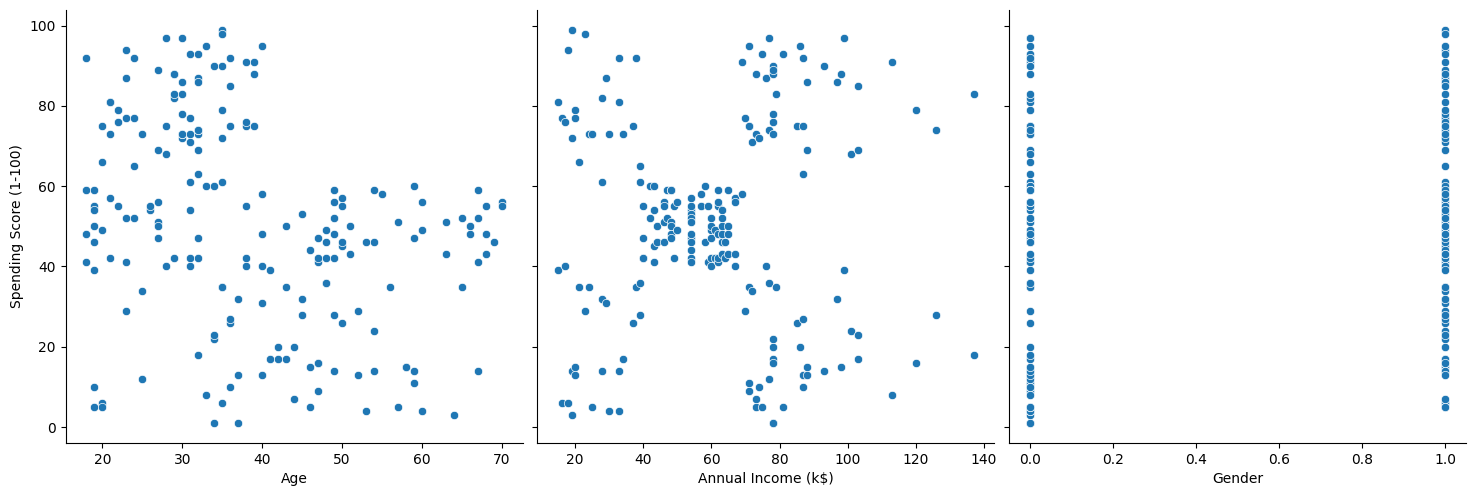

In [25]:
sns.pairplot(df_iqr,x_vars=['Age','Annual Income (k$)','Gender'],y_vars='Spending Score (1-100)',height=5,aspect=1)


Comment: From the abocve pairplot,it is evident that we see a pattern between


1.  Spending score vs Age
2.  Spending score vs Annual Income



# First form cluster based on spending score vs Age

In [26]:
X = df_iqr[['Annual Income (k$)','Spending Score (1-100)']]

In [27]:
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


# Finding the optimal value of k  using Elbow Method

# We get 2 parameters for the Kmeans models i.e.

1.   km.inertia_= SSE of that model
2.   km.cluster_centers= Stores the values of centroids



In [28]:
sse=[] #List to store sum of squares of error for each value of k for each model

In [29]:
for k in range(1,11):
  km=KMeans(n_clusters=k)
  km.fit(X)
  sse.append(km.inertia_)

In [30]:
sse

[269981.28000000014,
 183653.3289473683,
 106348.37306211119,
 82472.19413919412,
 44454.47647967972,
 37455.98455516028,
 32243.894362159568,
 31180.43074633699,
 21913.929201194416,
 21960.16902819403]

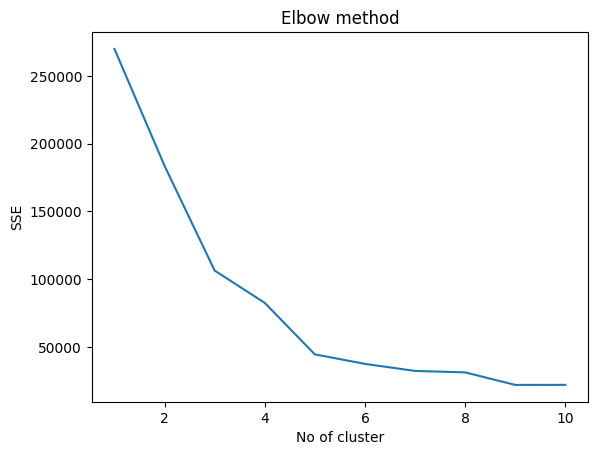

In [31]:
#Plot the  graph of Elbow-chart of K vs SSE
plt.plot(range(1,11),sse)
plt.title("Elbow method")
plt.xlabel("No of cluster")
plt.ylabel("SSE")
plt.show()

# Optimal value is k=5. So build the model for k=5

In [32]:
km=KMeans(n_clusters=5)# forming cluster with k=4
km

KMeans(n_clusters=5)

In [33]:
km = KMeans(n_clusters=5, random_state=42) # forming cluster with k=5
km.fit(X) # Explicitly fit the model
y_pred = km.predict(X) # Predict the clusters based on the fitted model

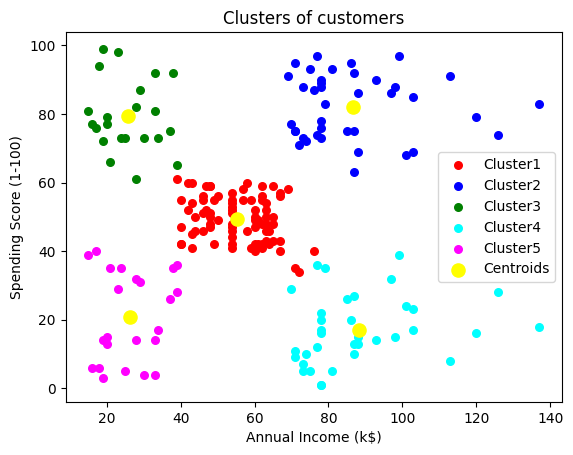

In [34]:
#Lets visualize the output cluster
plt.scatter(X.iloc[y_pred==0,0],X.iloc[y_pred==0,1],s=30,c='red',label='Cluster1')
plt.scatter(X.iloc[y_pred==1,0],X.iloc[y_pred==1,1],s=30,c='blue',label='Cluster2')
plt.scatter(X.iloc[y_pred==2,0],X.iloc[y_pred==2,1],s=30,c='green',label='Cluster3')
plt.scatter(X.iloc[y_pred==3,0],X.iloc[y_pred==3,1],s=30,c='cyan',label='Cluster4')
#plt.scatter(X.iloc[y_pred==3,0],X.iloc[y_pred==3,1],s=30,c='magenta',label='Cluster5')
plt.scatter(X.iloc[y_pred==4,0],X.iloc[y_pred==4,1],s=30,c='magenta',label='Cluster5')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],s=90,c='yellow',label='Centroids')
plt.title("Clusters of customers")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

Cluster Profiles:



*   Cluster 1 (Red):  
Customers with moderate income and moderate spending scores. They are budget-conscious and unlikely to respond to premium offers. Best suited for affordable products and promotions.

*   Cluster 2 (Blue):  
High-income customers with high spending scores.They are premium and high value customers.They should be prioritized with VIP treatment.
*   Cluster 3 (Green):  
Low-income customers with high spending scores. They are highly engaged despite not being the wealthiest. Ideal for loyalty programs.
*   Cluster 4 (Magenta):  
Low income customers with low spending scores.
They are budget consious and value driven.
*   Cluster 5 (Cyan):  
High income customers with low spending scores.They have strong finacial capacity but not engaged much.They could be highly profitable if activated.













# Now form cluster based on Spending score and Age

In [35]:
df_iqr

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40
...,...,...,...,...
195,1,35,120,79
196,1,45,126,28
197,0,32,126,74
198,0,32,137,18


In [38]:
df_iqr.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [40]:
X=df_iqr[['Age','Spending Score (1-100)']]


In [41]:
X

,Age,Spending Score (1-100)
0,19,39
1,21,81
2,20,6
3,23,77
4,31,40
...,...,...
195,35,79
196,45,28
197,32,74
198,32,18


#Finding optimal value of K using Elbow method

In [42]:
sse=[]

In [43]:
for k in range(1,11):
  km=KMeans(n_clusters=k)
  km.fit(X)
  sse.append(km.inertia_)

In [44]:
sse

[171535.50000000003,
 75949.15601023012,
 45844.53681626927,
 28165.583566629342,
 23907.65915694682,
 19818.581517393293,
 15571.061675474924,
 17147.393584656078,
 13642.121796600086,
 10588.993922130932]

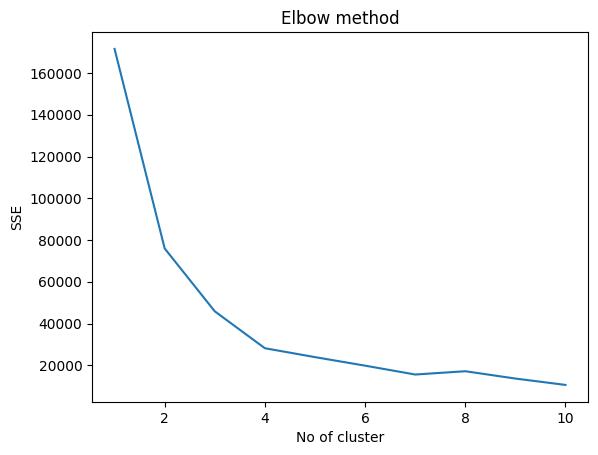

In [46]:
#Plot the graph of elbow-chart of k vs SSE
plt.plot(range(1,11),sse)
plt.title("Elbow method")
plt.xlabel("No of cluster")
plt.ylabel("SSE")
plt.show()

# Optimal value of K=4. rebuild the model for k=4

In [56]:
km=KMeans(n_clusters=4,random_state=42)
y_pred=km.fit_predict(X)

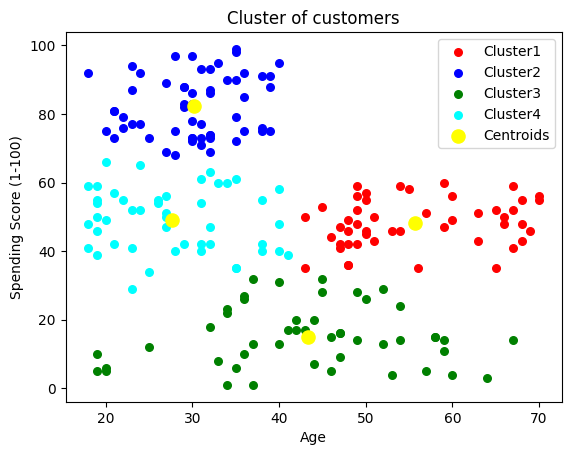

In [57]:
#Lets visualize the output cluster
plt.scatter(X.iloc[y_pred==0,0],X.iloc[y_pred==0,1],s=30,c='red',label='Cluster1')
plt.scatter(X.iloc[y_pred==1,0],X.iloc[y_pred==1,1],s=30,c='blue',label='Cluster2')
plt.scatter(X.iloc[y_pred==2,0],X.iloc[y_pred==2,1],s=30,c='green',label='Cluster3')
plt.scatter(X.iloc[y_pred==3,0],X.iloc[y_pred==3,1],s=30,c='cyan',label='Cluster4')
#plt.scatter(X.iloc[y_pred==4,0],X.iloc[y_pred==4,1],s=30,c='magenta',label='Cluster5')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],s=90,c='yellow',label='Centroids')
plt.title("Cluster of customers")
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

Cluster Profiles:

*   Cluster 1 (Red):  
Older customers with moderate spending scores. They represent a segment that spends occasionally but not heavily — potential to nurture into loyal buyers.


*   Cluster 2 (Blue):  
Younger to middle-aged customers with high spending scores. This is the most valuable group, showing strong purchasing behavior. They’re ideal for premium offerings, loyalty programs, and personalized experiences.

*   Cluster 3 (Green):  
Older customers with low spending scores. They appear conservative in spending, possibly less responsive to marketing campaigns. Best approached with cost-efficient engagement strategies.


*  Cluster 4 (Cyan):  
Younger to older customers with low spending scores. Likely price-sensitive or early-stage customers. Promotions, discounts, or entry-level products could help convert them into higher spenders.


